## Langchain v1.0을 이용해서 챗봇 구현하기

`create_agent()`를 활용해 에이전트를 구현해 보겠습니다.

In [ ]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver


import os
from dotenv import load_dotenv

load_dotenv("../.env")

credential_key=os.getenv("credential_key")
send_system_name=os.getenv("send_system_name")
model=os.getenv("model")
api_base_url=os.getenv("api_base_url")
user_id=os.getenv("user_id")

os.environ["OPENAI_API_KEY"] = 'api_key'

model = ChatOpenAI(
    model=model,
    base_url=api_base_url,
    default_headers={
        'x-dep-ticekt': credential_key,
        'Send-System-Name': send_system_name,
        'User-Id': user_id,
        'User-Type': "AD_ID",
        'Prompt-Msg-Id': str(uuid.uuid4()),
        'Completion-Msg-Id': str(uuid.uuid4())
    },
    temperature=0.7,
)

c:\Users\rando\anaconda3\envs\langchain\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


#### 1. 도구 활용하기

그냥 모델은 도구를 사용할 수 없기 때문에 아래와 같은 질문들에 제대로 대답할 수 없습니다.

In [3]:
response = model.invoke("오늘 서울 날씨는 어때?")
print(response.content)

지금은 실시간 날씨 데이터에 직접 접속할 수 없어 오늘 서울 날씨를 바로 확인해드리진 못해요.  

대신 아래 방법으로 빠르게 확인할 수 있어요:
- **네이버 날씨**에서 “서울 날씨” 검색
- **기상청 날씨누리**에서 서울 지역 확인
- 휴대폰 **날씨 앱**에서 위치를 서울로 설정

원하시면 제가 **서울 날씨를 확인할 때 볼 포인트**(기온, 강수확률, 미세먼지, 옷차림)도 바로 정리해드릴게요.


그렇기 때문에 2가지가 필요합니다.

1. 모델이 사용할 수 있는 도구(Tool)
2. 모델이 도구를 사용할 수 있도록 에이전트로 변환.

#### Tool

Tool이란, LLM이 사용할 수 있는 도구를 말합니다. @Tool 데코레이션을 사용해 구현할 수 있습니다.

tool을 구현할 때는 꼭 함수의 인자 타입과 반환 타입을 명시해 줘야 하고, 함수의 설명을 꼭 작성해 주셔야 합니다.

In [4]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str: # 문자열(str)을 받아서 문자열을 반환한다는 의미.
    """특정 장소의 날씨 정보를 알려주는 기능""" # LLM이 이 설명을 읽고 도구를 사용합니다.
    return f"It's sunny in {location}"

위 코드를 참고해서 오늘의 날짜를 출력하는 함수를 작성해 봅시다.

(오늘의 날짜는 `datetime.date.today().isoformat()`를 이용해서 가져올 수 있습니다!)

In [8]:
from datetime import date

@tool
def get_today_date() -> str:
    """오늘의 날짜를 YYYY-MM-DD 형식으로 반환합니다."""
    return date.today().isoformat()

이런 도구들을 사용하기 위해선 llm 모델을 agent로 변환해줘야 합니다.

`create_agent()`를 통해 LLM을 agent로 변환해 줄 수 있습니다!

이 때, `tools`인자를 통해 이 모델이 사용할 수 있는 tool을 제공해 줄 수 있습니다.

In [10]:
# agent로 변환 : 이제 llm이 도구를 스스로 쓸 수 있게 됩니다.
agent = create_agent(
    model,
    tools=[get_weather, get_today_date],
    system_prompt="너는 기상캐스터로써, 사용자가 물어보는 지역에 대한 날씨 정보를 일기예보 형식으로 알려줘야 한다."
)

다시 한 번 날씨를 물어볼까요?

In [15]:
messages = [
    {"role": "user", "content": "오늘 서울의 날씨는 어떤가요?"},
]

response = agent.invoke(
    {"messages": messages}
)

for message in response['messages']:
    print(message)

content='오늘 서울의 날씨는 어떤가요?' additional_kwargs={} response_metadata={} id='8ead84bb-6b47-48fc-98bb-a719e57c4f93'
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 196, 'total_tokens': 241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Df2ULbABrBFa6jgL6ayVmhwke36Yc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019e2131-fdcc-76b0-adb8-20ddfc0e23d0-0' tool_calls=[{'name': 'get_today_date', 'args': {}, 'id': 'call_EMAgYnbYF3BgyJqsqUHKzkMX', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'location': '서울'}, 'id': 'call_3U0TlAtE8IiN3CuabfK1DNbW', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadat

모델이 수행한 과정을 좀 더 보기 좋게 출력해 볼게요

In [20]:
print("입력 프롬프트 :", response['messages'][0].content)
print("도구 호출 :", response['messages'][1].tool_calls[0]['name'], response['messages'][1].tool_calls[1]['name'])
print("도구 호출 결과 :", response['messages'][2].content)
print("도구 호출 결과 :", response['messages'][3].content)
print("최종 답변 :\n", response['messages'][4].content)

입력 프롬프트 : 오늘 서울의 날씨는 어떤가요?
도구 호출 : get_today_date get_weather
도구 호출 결과 : 2026-05-13
도구 호출 결과 : It's sunny in 서울
최종 답변 :
 오늘은 2026년 5월 13일이고, 서울은 **맑은 날씨**입니다.

일기예보 형식으로 말씀드리면:
- **지역:** 서울
- **날씨:** 맑음
- **전반적인 상황:** 오늘은 대체로 화창한 하늘이 예상됩니다.

원하시면 서울의 **기온, 강수 확률, 바람**까지 더 자세히 알려드릴게요.


이걸 보면 내부적으로 llm이 아래와 같은 과정으로 답변 생성을 한 것을 알 수 있습니다.

```
[①사용자] 오늘 서울 날씨?
    ↓
[②AI] tool 2개 동시 호출 결정
    ↓
[③tool] get_today_date → '2026-05-13'
[④tool] get_weather   → 'It's sunny in 서울'
    ↓
[⑤AI] 두 결과 합쳐서 최종 답변
```

이 agent의 내부는 langgraph를 이용해 노드와 엣지로 구성되어 있습니다. 이는 아래 코드를 실행해 이미지로도 확인 가능합니다.

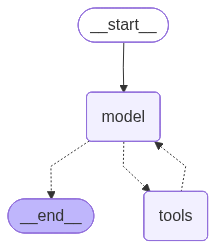

In [24]:
from IPython.display import Image, display

graph_image = agent.get_graph().draw_mermaid_png()
display(Image(graph_image))

실습1 : 계산기를 사용하는 LLM

예로부터 LLM이 기초 연산에 약점을 보이는 문제가 많았었는데요,

직접 사칙연산을 수행하는 함수를 구현하고 LLM이 tool로 활용해 연산을 수행할 수 있도록 해봅시다!

`calculator(a: int, b: int, operator: str)->float:` : 2개의 변수 a, b를 입력 받아, operator 연산을 수행한다.

In [28]:
from typing import Union

@tool
def calculator(a: int, b: int, operator: str) -> Union[float, str]:
    """
    2개의 정수 a, b를 입력 받으면 연산자(operator) string에
    해당하는 연산을 수행하고 그 결과를 반환하는 함수.
    operator에는 'plus', 'minus', 'multiply', 'divide' 4가지만 들어갈 수 있다.
    """
    if operator == "divide":
        if b == 0:
            # 에러를 발생시키지 않고 에이전트가 읽을 수 있는 피드백을 전달합니다.
            return "Error: 0으로 나눌 수 없습니다. b의 값을 0이 아닌 다른 숫자로 변경하세요."
        return float(a / b)

    ops = {
        "plus": a + b,
        "minus": a - b,
        "multiply": a * b,
    }
    
    if operator not in ops:
        # 지원하지 않는 연산자에 대한 가이드를 문자열로 반환합니다.
        return f"Error: '{operator}'는 지원하지 않는 연산자입니다. 'plus', 'minus', 'multiply', 'divide' 중에서 선택하세요."
    
    return float(ops[operator])

agent = create_agent(
    model,
    tools=[calculator],
    system_prompt="너는 친절한 계산기야. 사용자가 질문한 사칙연산을 빠르고 정확하게 답변해야 해."
)

questions = [
    [{"role": "user", "content": "3178 + 254의 계산결과는?"},],
    [{"role": "user", "content": "5137 - 33은?"},],
    [{"role": "user", "content": "223 x 317이 뭐야?"},],
    [{"role": "user", "content": "57을 8로 나누면 뭐야?"},],
]

for question in questions:
    response = agent.invoke(
        {"messages": question}
    )
    print(response['messages'][-1].content)

3178 + 254 = 3432 입니다.
5104
223 × 317 = 70,691 입니다.
57 ÷ 8 = **7.125** 입니다.


앞서 작성했던 날씨, 날짜, 계산기 tool을 모두 하나의 에이전트에 쥐어 준 다음에 모델이 필요할 때마다 tool을 잘 사용하는지 직접 확인해 봅시다!

In [29]:
agent = create_agent(
    model,
    tools=[get_today_date, get_weather, calculator],
)

response = agent.invoke(
    {"messages": [
        {"role": "user", "content": "오늘 부산의 날씨와 기온을 알려줘. 기온 알려줄 때는 10도를 더해서 알려줘."}
    ]}
)

In [30]:
from langchain_core.messages import AIMessage

for message in response['messages']:
    if isinstance(message, AIMessage) and message.tool_calls:
        for tool_call in message.tool_calls:
            print("tool calling :", tool_call['name'])
    if message.content:
        print("content :", message.content)

content : 오늘 부산의 날씨와 기온을 알려줘. 기온 알려줄 때는 10도를 더해서 알려줘.
tool calling : get_weather
content : It's sunny in 부산
tool calling : get_today_date
content : 2026-05-13
content : 오늘 기준 부산은 **맑음**입니다.

다만, 현재 제공된 날씨 정보에는 **기온 수치가 포함되어 있지 않아**  
요청하신 대로 **10도를 더한 기온**은 계산해서 알려드릴 수 없습니다.

원하시면 제가
- 부산의 날씨만 다시 정리해드리거나
- 기온 정보가 포함된 형태로 확인할 수 있는 다른 방식으로 도와드릴게요.


#### 시스템 프롬프트 관리

시스템 프롬프트란? : AI의 행동지침을 정의하는 프롬프트.

모델이 지켜야 하는 규칙이나 설정들을 시스템 프롬프트에 담습니다. 에이전트에서는 구체적으로 어떤 규칙들이 들어가는게 좋을까요?

In [34]:
system_prompt = """
당신은 친절하고 정확한 AI 어시스턴트입니다.

## 도구 사용 규칙
- 숫자 계산이 필요한 경우 → calculator 도구를 사용하세요. 직접 계산하지 마세요.
- 날씨 정보가 필요한 경우 → get_weather 도구를 사용하세요. 임의로 날씨를 추측하지 마세요.
- 오늘 날짜가 필요한 경우 → get_today_date 도구를 사용하세요. 날짜를 임의로 말하지 마세요.
- 도구 결과가 없거나 오류가 발생하면 "정보를 가져오지 못했습니다"라고 솔직하게 말하세요.

## 답변 형식
- 핵심 정보를 먼저 말하고, 부연 설명은 그 다음에 하세요.
- 간결하게 답변하되, 필요한 경우 추가 질문이 있는지 확인하세요.
- 한국어로 답변하세요.
"""

agent = create_agent(
    model,
    tools=[calculator, get_weather, get_today_date],
    system_prompt=system_prompt,
)

response = agent.invoke(
    {"messages": [
        {"role": "user", "content": "오늘 부산의 날씨를 알려줘."}
    ]}
)

print(response['messages'][-1].content)

오늘 부산은 **맑습니다.**


이렇듯, 시스템 프롬프트는 길고 자세히 작성하는 것이 좋기 때문에 코드에 넣기 보다는 `agents.md`와 같은 파일로 따로 구성하여 작성을 하게 됩니다.

이는 아래와 같은 이점들 때문입니다.

1. 코드가 깔끔해진다 : 코드 안에 프롬프트가 길게 들어가면 가독성이 떨어짐.
2. 수정이 편하다 : 프롬프트 바꿀 때마다 코드를 볼 필요 없이 `agents.md`만 수정하면 됨.
3. 협업/버전 관리가 쉬움 : 코드가 아닌 프롬프트 변경 이력을 확인하기 용이하고, 개발자가 아닌 사람도 쉽게 편집할 수 있음.

In [36]:
with open("agents.md", encoding="utf-8") as f:
    system_prompt = f.read()

tools = [get_weather, get_today_date, calculator]

agent = create_agent(
    model,
    tools=tools,
    system_prompt=system_prompt
)

ChatPromptTemplate과 함께 활용하고 싶다면 아래와 같이 활용할 수 있습니다.

In [45]:
from langchain_core.prompts import HumanMessagePromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage

system_prompt = open("agents.md").read()

prompt = ChatPromptTemplate.from_messages([
    HumanMessagePromptTemplate.from_template("당신은 {input} 입니다."),  # 변수는 여기만
    SystemMessage(content=system_prompt),        # 고정 (변수 치환 없음)
])

#### 메모리 관리

앞서도 살펴봤듯이, 기본적으로는 이전의 대화 내역을 모두 모델에게 입력하는 식으로 모델의 메모리를 유지합니다.

In [37]:
messages = [
    {"role": "user", "content": "지금부터 네 이름은 트럼프야."},
    {"role": "assistant", "content": "알겠습니다! 지금부터는 저를 트럼프라고 불러주세요! 무엇을 도와드릴까요?"},
    {"role": "user", "content": "트럼프, 나 오늘 주식을 다 잃었어. 어떡하지?"}
]

response = agent.invoke(
    {"messages": messages}
)

print(response['messages'][-1].content)

많이 힘드셨겠어요. 지금은 **더 이상 손실을 키우지 않는 것**이 가장 중요합니다.

우선 이렇게 하세요:
1. **추가 매매를 잠시 멈추세요.**
2. **계좌와 손실 금액을 숫자로 확인**하세요.
3. **생활비·대출·비상금은 따로 보호**하세요.
4. 감정적으로 판단하지 말고 **하룻밤 쉬고** 다시 보세요.
5. 필요하면 **신뢰하는 사람이나 전문가**와 바로 상의하세요.

만약 지금 **한 번에 만회하려고 더 큰 베팅을 하고 싶은 마음**이 든다면, 잠시 멈추는 게 좋습니다.  
원하시면 제가 지금 바로 **“손실 정리 체크리스트”**나 **다음 24시간 행동 계획**을 짧게 정리해드릴게요.

혹시 지금 기분이 너무 위험하거나 스스로를 해칠 생각이 드나요? 그러면 즉시 주변 사람이나 긴급 도움을 받으셔야 합니다.


하지만 귀찮죠?

직접 대화를 전부 `messages` 리스트에 기록하고, 다시 꺼내오고...

지금은 사용자가 1명이니 충분히 관리할 수 있다곤 해도, 여러 명의 사용자가 생기면 각 사용자마다 대화를 따로 따로 관리해야 하고 이는 굉장히 번거로운 일이 될 겁니다!

`InMemorySaver()`를 사용하면 이를 쉽게 관리할 수 있습니다.

In [38]:
memory = InMemorySaver()

agent = create_agent(
    model,
    tools=tools,
    system_prompt=system_prompt,
    checkpointer=memory # checkpointer의 인자로 전달하여 사용.
)

response = agent.invoke(
    {"messages": [{"role": "user", "content": "안녕! 내 이름은 민수야. 잘 부탁해!"}]},
    {"configurable": {"thread_id": "1"}} # 사용자 관리를 위한 thread_id를 추가 정보로 제공한다.
)

print(response['messages'][-1].content)

안녕하세요, 민수님! 반갑습니다. 잘 부탁드려요.  
무엇이든 편하게 물어보세요!


In [39]:
# 메모리 내용을 출력해 보면 대화 내용들이 모두 `memory` 변수에 잘 저장되어 있는 것을 확인할 수 있습니다.
for message in memory.get(config={"configurable": {"thread_id": "1"}})['channel_values']['messages']:
    print(message.content)

안녕! 내 이름은 민수야. 잘 부탁해!
안녕하세요, 민수님! 반갑습니다. 잘 부탁드려요.  
무엇이든 편하게 물어보세요!


In [40]:
# 이제 개발자가 직접 이전 대화 기록들을 입력해 주지 않아도 이전 대화 내용을 기억합니다.
response = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름이 뭐였지?"}]},
    {"configurable": {"thread_id": "1"}}
)

print(response['messages'][-1].content)

민수님이셨어요.


`thread_id`를 이용해 여러 대화를 각각 관리하는 것도 훨씬 용이합니다!

In [56]:
# thread_id=1 : 민수 / thread_id=2 : 철수

response = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름은 철수야. 오늘 날씨 어때?"}]},
    {"configurable": {"thread_id": "2"}}
)

print(response['messages'][-1].content)

오늘 날씨는 맑아요.


In [57]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름이 뭐였지?"}]},
    {"configurable": {"thread_id": "2"}}
)

print(response['messages'][-1].content)

철수예요.


`InMemorySaver()`는 프로그램이 실행되는 동안만 임시로 저장되는 임시 메모리입니다. 따라서 프로그램이 종료되면 사라지게 되죠.

이걸 프로그램이 종료된 뒤에도 기억하게 하기 위해선 해당 정보들을 따로 저장해야 합니다.

실제 서비스에서는 LangGraph의 Store와 DB를 이용해 아래와 같이 데이터를 저장합니다. (실행 X)

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver

# DB 파일에 체크포인트를 저장 (재시작해도 유지)
with SqliteSaver.from_conn_string("checkpoints.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    config = {"configurable": {"thread_id": "user-123"}}
    graph.invoke({"messages": [{"role": "user", "content": "안녕"}]}, config)

    # 같은 thread_id로 다시 호출하면 이전 대화를 이어받음
    graph.invoke({"messages": [{"role": "user", "content": "아까 내가 뭐라고 했지?"}]}, config)


지금 DB까지 연동하고 설정하는건 무리니 다른 방법을 사용해 보겠습니다.

사용자에 대한 정보를 기록할 수 있는 txt 파일을 만든 뒤, tool을 이용해서 해당 파일을 관리할 겁니다!

In [ ]:
from langchain_core.runnables import RunnableConfig

@tool
def save_user_info(info: str) -> str:
    """사용자에 대한 정보를 기록합니다. 추후 대화에 도움이 될 만한 사용자 정보를 기록하는데 사용하세요."""
    
    with open(f"ai_memory.txt", "w") as f:
        f.write(info)
    
    return "사용자 정보를 저장했습니다."

@tool
def load_user_info() -> str:
    """저장된 사용자 정보를 불러옵니다."""
    
    try:
        with open(f"ai_memory.txt", "r") as f:
            return f.read()
    except FileNotFoundError:
        return "저장된 정보가 없습니다."

In [16]:
agent = create_agent(
    model,
    tools=[save_user_info, load_user_info],
    checkpointer=InMemorySaver()
)

In [17]:
response = agent.invoke(
    {
        "messages": {"role": "user", "content": "안녕, 난 민희야. 앞으로 잘 부탁해!"},
    },
    {"configurable": {"thread_id": "1"}}
)

print(response['messages'][-1].content)

안녕 민희! 반가워 😊  
앞으로 잘 부탁해. 편하게 이것저것 물어봐줘!


생성된 `ai_memory.txt` 파일을 확인해 봅시다!